### Testing methods of Creating erorr Bars over 

1. First method is creating, 2dHistogram (binning all data). 
    - The averge over longitude - blue bars 
    - Calcuating error from the different latitude slices of the predetrmined bins 
    - Results: Gets a correct error but small sample size, only has 30 latitude slices
2. Second Method starts the same as first 
    - Then does a "slideing latitude slice window". 
    - this gives larger sample size of errrors to calcuate from 
3. Third attempt is resampling over all the data samples - very wrong
    - Resample with replacement all of the data samples, Calcuate averages from this 
4. Fourth attempt:
    - Resamples along one latitude, Breaks the lattitude row into 6-12 bins, then resamples the bins randomly. with the same length as the row. so resamples 6-12 bins. 


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import functions.funcs as funcs

In [2]:
ds = gpd.read_parquet(r"Data\SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet")

data  = funcs.generate_longlist(ds)
print(data.columns)
lon = data['lons']
lat = data['lats']

Index(['Time', 'BuoyID', 'lats', 'lons', 'x_speed', 'y_speed'], dtype='object')


In [3]:
## first lets create bin sizes of 0.1 deg 
print(max(lon), min(lon))
print(max(lat),min(lat))

lat_range = np.arange(min(lat), max(lat), 0.1)
lon_range = np.arange(min(lon), max(lon), 0.1)

print(lat_range.shape)
print(lon_range.shape)

-160.66668 -163.74997
7.7503 4.50002
(33,)
(31,)


In [4]:
def histogram2d(data, bins = 100):
    lon = data['lons']
    lat = data['lats']

    gridded, lonedges, latedges  = np.histogram2d(lon,lat,bins = bins)
    gridded = gridded.T
    return gridded, lonedges, latedges

#### Method 1: Cacluating error Bars based off of variations in longitude. compaired each slice at diffent longitudes. 

In [5]:
Gridded, lonedges, latedges = histogram2d(data,bins = [lon_range,lat_range])
#Gridded.shape ##(lat,lon) = (32,30)


lat_mean = np.mean(Gridded,axis = 1)/3 ## convets to /year/0.1 deg
lat_mean[13] = np.mean(lat_mean)
errors = np.percentile(Gridded/3,95,axis = 1)
print(errors.shape)
error_bar = errors - lat_mean
error_bar[13] = np.mean(error_bar)
print (error_bar)

(32,)
[18.24444444 23.33888889 22.22222222 20.67222222 24.61666667 16.26111111
 17.62777778  9.54444444 17.85555556 13.14444444 12.34444444 13.87777778
 13.05       16.24057075 20.54444444 11.52222222  9.69444444 17.92222222
 17.57777778 15.88333333 15.75       14.05555556 14.79444444 15.11666667
 14.89444444  9.63333333 10.81666667 13.13888889 14.91666667 14.57777778
 19.56666667 15.62777778]


<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17968\2935622983.py:4: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")


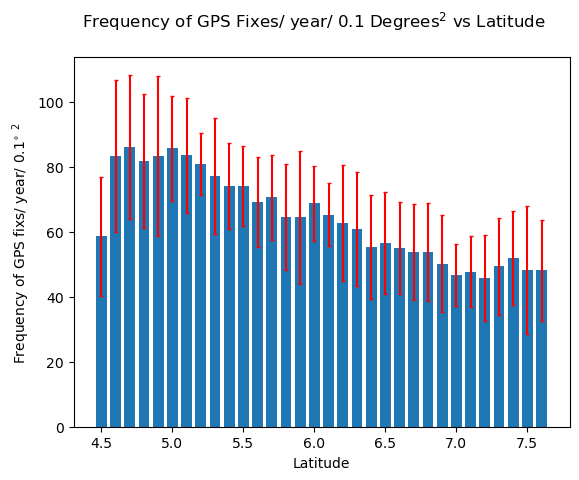

In [6]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle("Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings3.png")

In [7]:
lonstart_list = np.random.rand(1000)*(lonedges[-1] - lonedges[0])+lonedges[0]
# window = np.array([lonstart[0], lonstart[0]+0.1])
# print(window)
#print(lonstart_list)

#### Method 2: Slideing Window - Trying to sample diffent longitudes with the same 

In [8]:
##latedges, lonedges
Gridded_list = []
lonstart_list = np.random.rand(1000)*(lonedges[-1] - lonedges[0])+lonedges[0]
for i in range(1000):
    window = np.array([lonstart_list[i], lonstart_list[i]+0.1])
    #print(window)
    gridded, lonedges, latedges = histogram2d(data, bins = [window,lat_range])

    Gridded_list.append(gridded)

In [9]:
gridded = np.array(Gridded_list)
print(gridded[:,:,0].shape)
gridded = gridded.reshape((1000,32))/3
print(gridded.shape)


(1000, 32)
(1000, 32)


In [10]:
##calcuating error
errors = np.percentile(gridded,95,axis = 0)
error_bar = errors - lat_mean
error_bar[13:15] = np.mean(error_bar)
print (error_bar)
Gridded, lonedges, latedges = histogram2d(data,bins = [lon_range,lat_range])


lat_mean = np.mean(Gridded,axis = 1)/3 ## convets to /year/0.1 deg
lat_mean[13:15] = np.mean(lat_mean)

[20.79444444 27.77222222 27.88888889 21.47222222 25.03333333 17.34444444
 20.51111111 12.17777778 18.95555556 14.56111111 15.34444444 13.84444444
 15.4        17.78692491 17.78692491 11.18888889 12.41111111 19.68888889
 18.19444444 15.7        16.05       19.68888889 15.12777778 16.26666667
 16.86111111 10.31666667 11.23333333 13.62222222 15.98333333 15.37777778
 21.43333333 14.24444444]


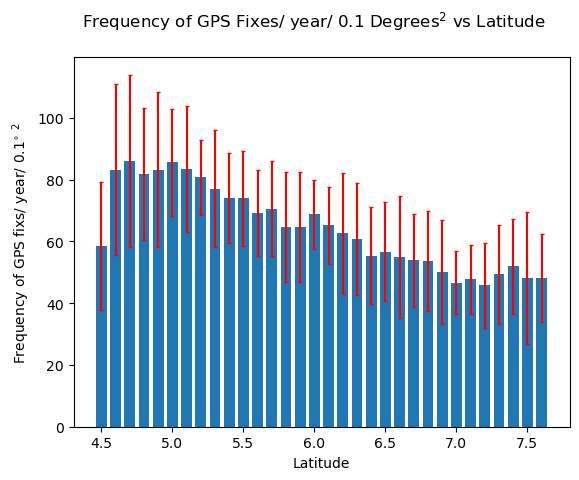

In [11]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel(r"Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle(r"Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings4.png")

#### MEthod 3: Resampling over the whole domain

In [12]:
total_num = data.shape[0]

Gridded_list = []
for n in range(1000):
    sample  = data.sample(n = total_num, replace = True)

    gridded, lonedges, latedges = histogram2d(sample, bins = [lon_range,lat_range])

    Gridded_list.append(gridded)

In [13]:
print(latedges)

[4.50002 4.60002 4.70002 4.80002 4.90002 5.00002 5.10002 5.20002 5.30002
 5.40002 5.50002 5.60002 5.70002 5.80002 5.90002 6.00002 6.10002 6.20002
 6.30002 6.40002 6.50002 6.60002 6.70002 6.80002 6.90002 7.00002 7.10002
 7.20002 7.30002 7.40002 7.50002 7.60002 7.70002]


In [14]:
Stacked = np.stack(Gridded_list, axis = 0)

mean_2d = np.mean(Stacked, axis= 0)
print(mean_2d.shape)

lat_mean = np.mean(mean_2d, axis = 1) ##Mean value to be plotted.
lat_mean[13] = np.mean(lat_mean)

lat_mean = lat_mean/30/3 ## averages over 0.1 degree in latitude. and per year 


##calcuating error
x = np.mean(Stacked, axis = 2)/30/3
print(x.shape)
errors = np.percentile(x,95,axis = 0)
error_bar = errors - lat_mean
error_bar[13] = np.mean(error_bar)
print (error_bar)

(32, 30)
(1000, 32)
[0.0405063  0.04716407 0.05161481 0.05005    0.05056741 0.05205259
 0.05334778 0.0512337  0.0503037  0.04940111 0.04697037 0.04755
 0.04500741 0.05440131 0.04321926 0.04596667 0.0435337  0.04639593
 0.04263593 0.04227148 0.04235444 0.04128667 0.04221148 0.03969556
 0.03988519 0.03728556 0.04037815 0.03857704 0.04201741 0.04256556
 0.04116852 0.04067556]


<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17968\496465850.py:4: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")


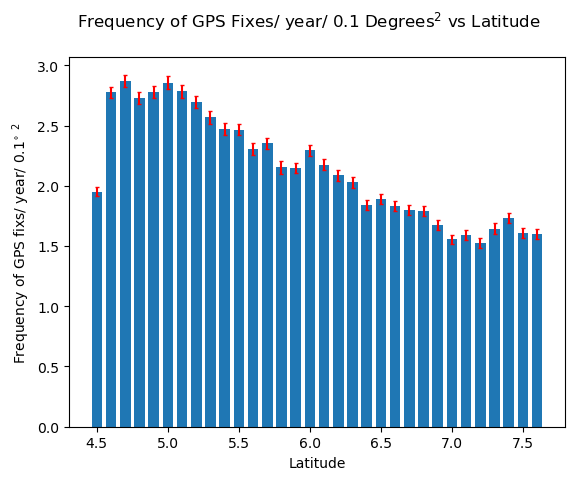

In [15]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle("Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings2.png")

#### Method 4 

In [16]:
Binned_data, lonedges, latedges  = histogram2d(data, bins = [lon_range,lat_range])

print(Binned_data.shape)
mean_array = []
np.random.seed(50)
for n in range(1000):
    Randidex  = np.random.randint(0,30,30)
    #print(Randidex)
    selected_bins = []
    for i in Randidex:
        selected_bins.append(Binned_data[:,i])


    selected_bins = np.array(selected_bins)
    #print(selected_bins)
    mean_array.append(np.mean(selected_bins, axis = 0))

(32, 30)


In [17]:
mean_array = np.array(mean_array)
print(mean_array.shape)
errors = np.percentile(mean_array,95,axis = 0)/3
print(errors.shape)
lat_mean2 = np.mean(Binned_data,axis =1)/3 ##this is non bootstrapping data 
lat_mean = np.mean(mean_array,axis = 0)/3
#print(lat_mean)
#print(lat_mean2)
error_bar = errors - lat_mean
#error_bar[13] = np.mean(error_bar)
error_bar[13] = np.mean(error_bar)
lat_mean[13] = np.mean(lat_mean)
np.mean(lat_mean)


(1000, 32)
(32,)


np.float64(64.28915627170139)

In [18]:
Mean_dfads = np.mean(lat_mean) ## dFADs/year/0.1^2
Mean_dfads*8.905/24/365#/11.1/11.1*25*25 

np.float64(0.0653533032647832)

#### Combining method 4 with what zonal currents are doing

- Resampling in latitude slices 

In [19]:
import xarray as xr
climat = xr.open_dataset(r"Data\drifter_monthlymeans_f43a_401f_20bd_U1775085192326.nc")
climat = climat.rename({"latitude" : "lat", "longitude": "lon", "U": "uo", "V": "vo"})

In [20]:
longlist = data.copy()

longlist['year'] = longlist.Time.dt.year
longlist['month'] = longlist.Time.dt.month
month_bins = np.array([1,4,7,10,13])
longlist['season'] = pd.cut(longlist['month'], month_bins, right = False) # makes it [a,b) months 1-3, 4-6,7-9, 10-12

def calc_lat_average(longlist):
    lat_bins = np.arange(4.5,7.76, 0.25)
    longlist['lat_bin'] = pd.cut(longlist.lats, lat_bins, right = False)
    profiles = pd.DataFrame()
    for n, bin in enumerate(longlist.season.unique().dropna().sort_values()):
        season = longlist[longlist['season'] == bin]
        profile =season.groupby('lat_bin', observed=False)['x_speed'].mean()
        profiles[n+1] = profile
    profiles = profiles.reset_index()
    profiles['lats'] = lat_bins[profiles.index] + np.diff(lat_bins)/2
    return profiles

profiles = calc_lat_average(longlist)

box7 = climat.sel(lat = slice(0, 10), lon = slice(-163.75, -160.5))
box7 = box7.mean(dim = "lon")

In [21]:
## calc mean statistics based on speeds 
zonalm = longlist.x_speed.mean()
zonalstd = longlist.x_speed.std()
merdianalm = longlist.y_speed.mean()
merdianalstd = longlist.y_speed.std()


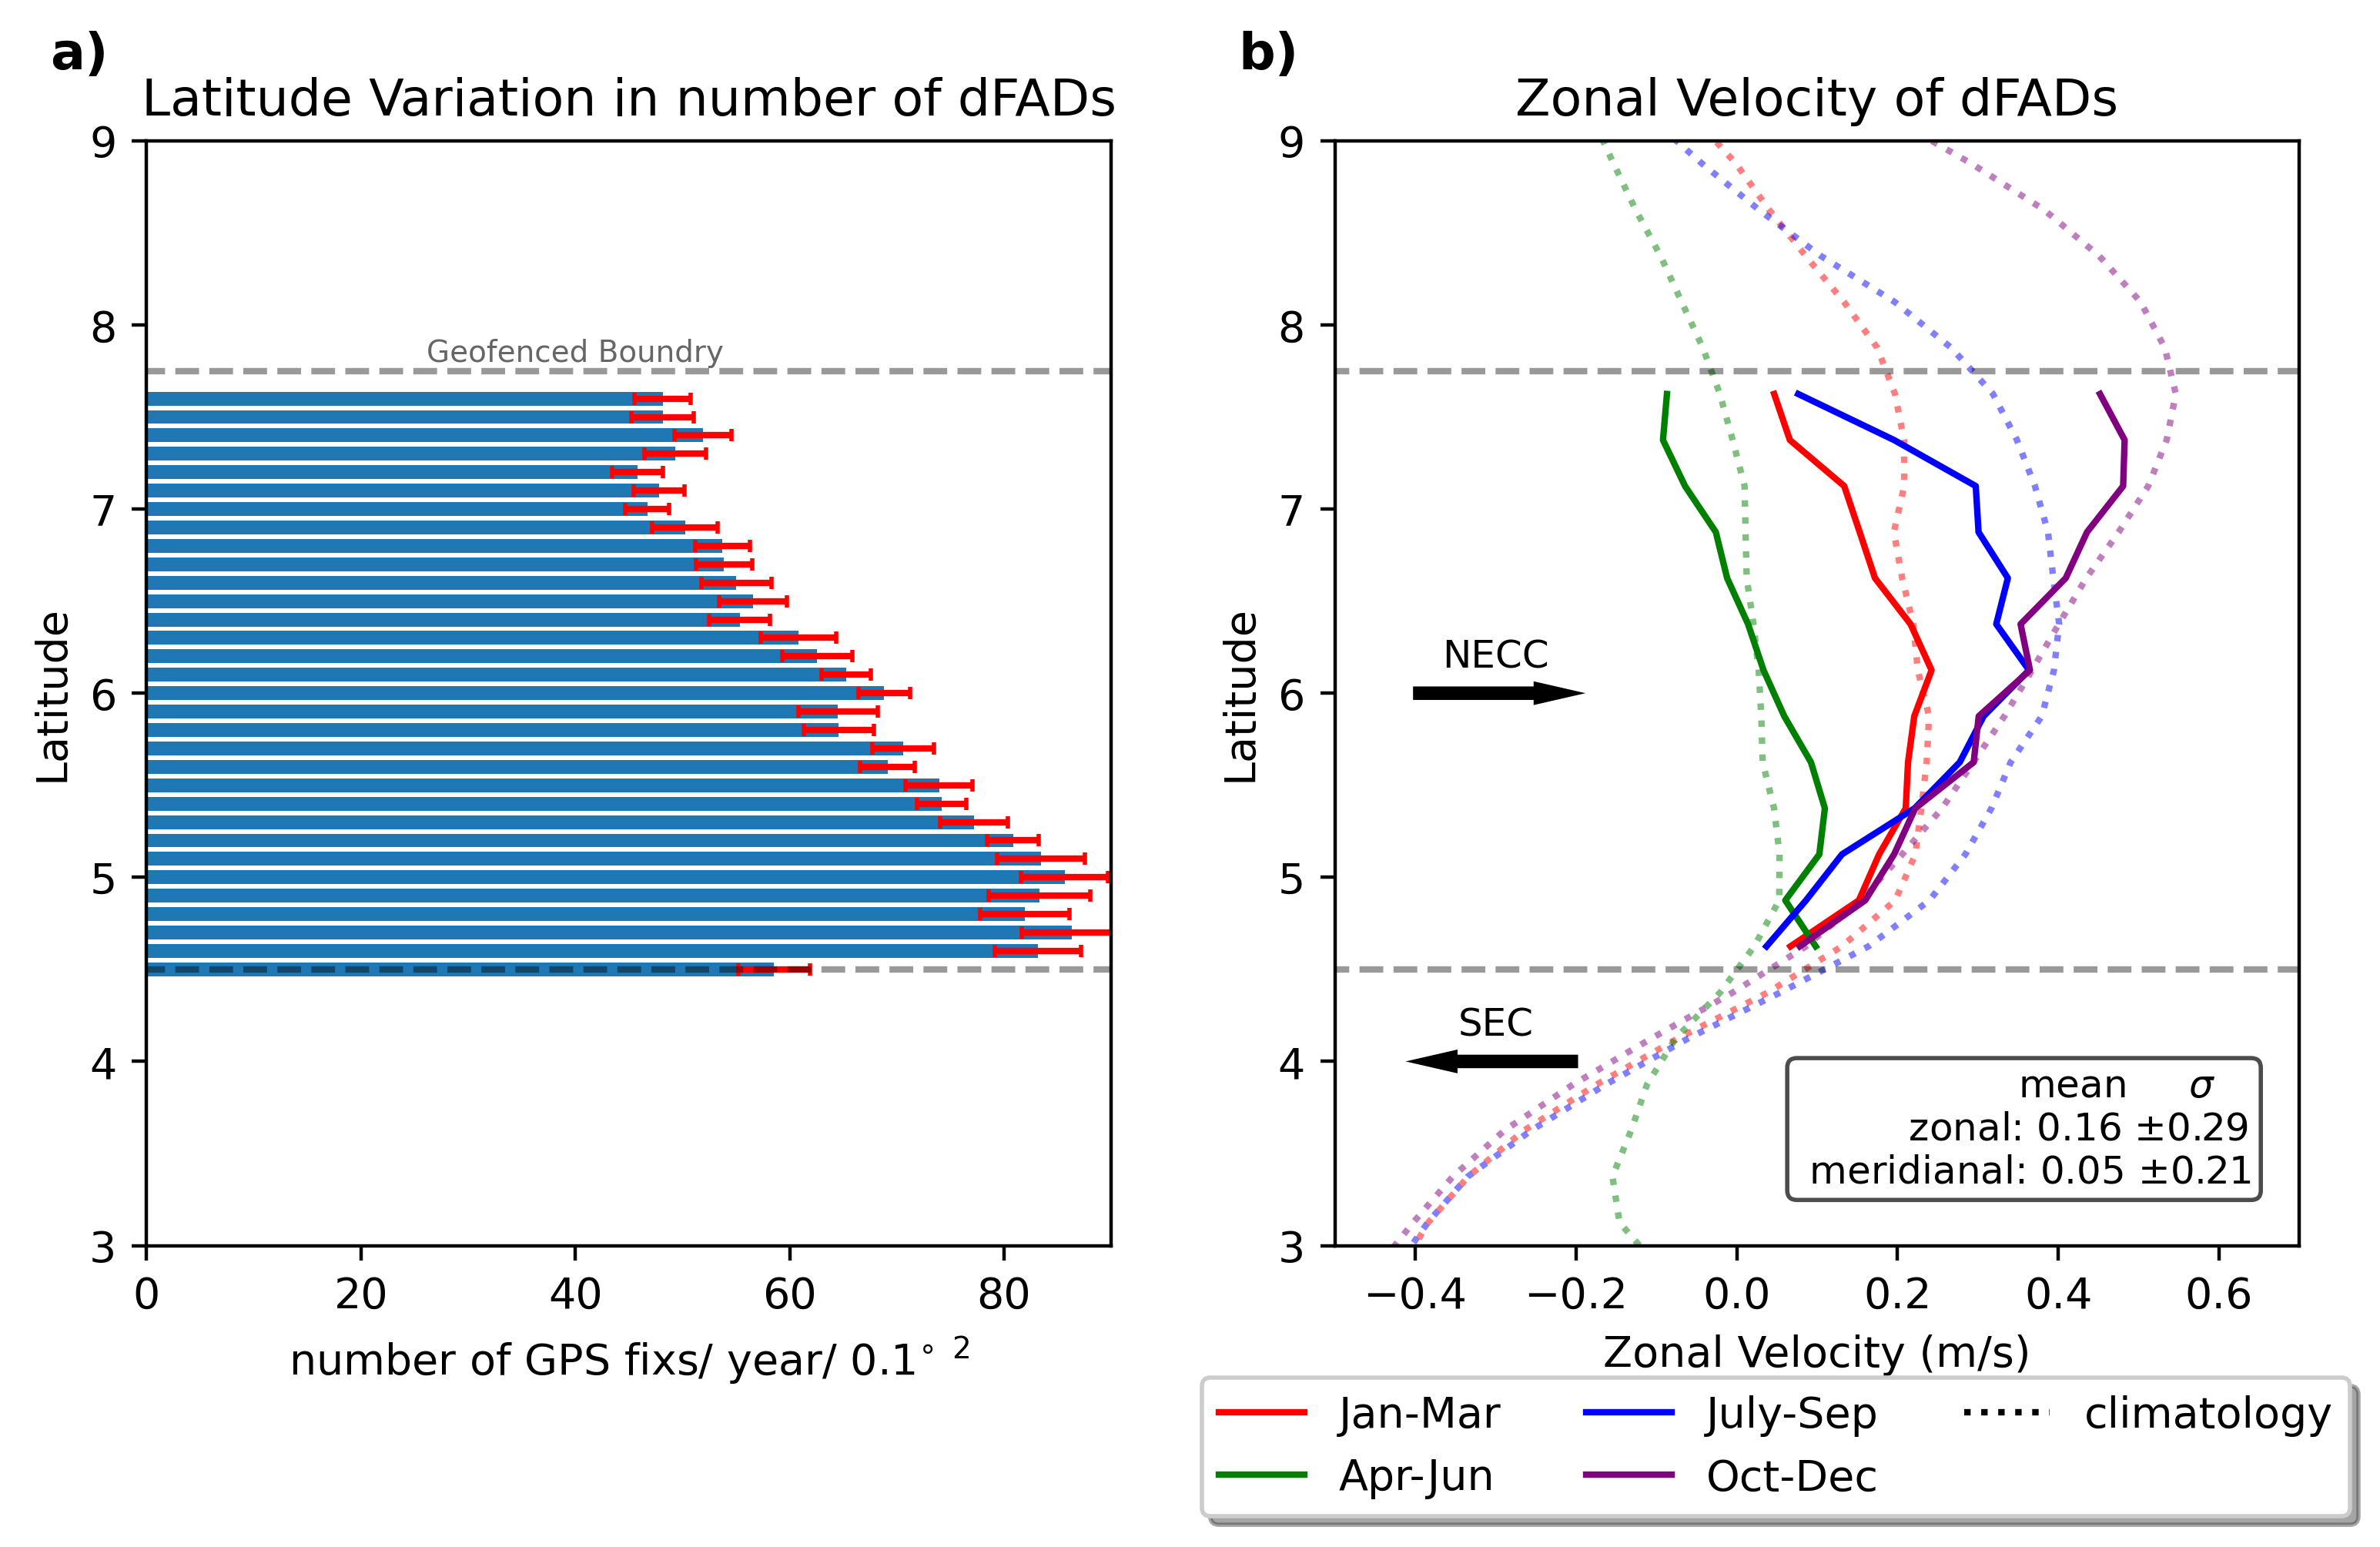

In [29]:
fig, axs = plt.subplots(1,2, figsize = (8,5), dpi = 400)
ax, ax1 = axs
miny, maxy = [3, 9]
ax.barh(latedges[:-1], lat_mean, height=0.075, xerr=error_bar, ecolor="r", capsize=1.5)
ax.set_ylabel("Latitude")
ax.set_xlabel(r"number of GPS fixs/ year/ 0.1$^{\circ}$ $^2$")
ax.set_title("Latitude Variation in number of dFADs")
ax.set(ylim = [miny, maxy], xlim = [0,90])
colors = ['r', 'g', 'b', 'purple']
titles = ['Jan-Mar' , 'Apr-Jun', 'July-Sep', 'Oct-Dec']
for i in range(4):
    ax1.plot(profiles[i+1], profiles.lats, c = colors[i], label = titles[i])
    ax1.plot(box7.uo[i*3:(i+1)*3,:].mean(dim = "ClimatologicalMonth"), box7.lat, c = colors[i], ls = ':', alpha = 0.5)
ax1.set(title = 'Zonal Velocity of dFADs',xlabel = 'Zonal Velocity (m/s)', ylabel= 'Latitude', ylim= [miny, maxy], xlim =[-0.5, 0.7])
ax1.plot([], [], c='k', ls=':', label='climatology') ## too be added to legend 
ax1.legend(loc='upper center', bbox_to_anchor=(3.2/7, -0.1),
           fancybox=True, shadow=True, ncol=3)
text = f'mean     $\\sigma$    \n zonal: {zonalm:0.2f} $\\pm${zonalstd:0.2f} \n meridianal: {merdianalm:0.2f} $\\pm${merdianalstd:0.2f}'
ax1.text(0.95,0.05,text,  transform=ax1.transAxes,
            ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="black"))
for axi in axs: 
    axi.hlines([7.75, 4.5], -10, 100, color = 'k', alpha = 0.4, ls = '--')

ax1.arrow(-0.2, 4.0, -0.2, 0.0,   width=0.05, head_width=0.1, 
    head_length=0.05, length_includes_head=True, color="black")
ax1.text(-0.3, 4.3, "SEC", fontsize=9, ha="center", va="top")


ax1.arrow(-0.4, 6, 0.2, 0.0,   width=0.05, head_width=0.1, 
    head_length=0.05, length_includes_head=True, color="black")
ax1.text(-0.3, 6.3, "NECC", fontsize=9, ha="center", va="top")

ax.text(40, 7.8, 'Geofenced Boundry', ha = 'center', fontsize = 7, alpha = 0.6)
fig.tight_layout()
ax.text(-0.1, 1.1, 'a)', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
ax1.text(-0.1, 1.1, 'b)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top')
fig.savefig(r'..\Figures\paper\FIG2.pdf', format = 'pdf')
